<a href="https://colab.research.google.com/github/abhilash2105/PS-neuro/blob/main/small_EEG_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q mne scipy scikit-learn matplotlib

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import mne

from sklearn.preprocessing import StandardScaler

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
!wget -q https://physionet.org/files/eegmmidb/1.0.0/S001/S001R04.edf
!wget -q https://physionet.org/files/eegmmidb/1.0.0/S001/S001R08.edf
!wget -q https://physionet.org/files/eegmmidb/1.0.0/S001/S001R12.edf

print("EEG recordings downloaded!")

EEG recordings downloaded!


In [ ]:
files = ["/content/S001R04.edf",
    "/content/S001R08.edf",
    "/content/S001R12.edf"
]

print("EEG files:")

for file in files:
    if os.path.exists(file):
        print("✓", os.path.basename(file))
    else:
        print("✗ Missing:", file)

EEG files:
✓ S001R04.edf
✓ S001R08.edf
✓ S001R12.edf


In [ ]:
files = [
    "/content/S001R04.edf",
    "/content/S001R08.edf",
    "/content/S001R12.edf"
]

raw_list = []

for file in files:

    print("Loading:", os.path.basename(file))

    raw_data = mne.io.read_raw_edf(
        file,
        preload=True,
        verbose=False
    )

    raw_list.append(raw_data)

print("\nAll recordings loaded!")

Loading: S001R04.edf
Loading: S001R08.edf
Loading: S001R12.edf

All recordings loaded!


In [ ]:
for i, raw_data in enumerate(raw_list):

    print("\n" + "=" * 50)

    print("Recording:", os.path.basename(files[i]))

    print("Number of channels:", len(raw_data.ch_names))

    print("Sampling frequency:",
          raw_data.info["sfreq"],
          "Hz")

    print("Duration:",
          round(raw_data.times[-1], 2),
          "seconds")

    print("\nChannel names:")
    print(raw_data.ch_names)

    print("\nAnnotations:")
    print(raw_data.annotations.description)


Recording: S001R04.edf
Number of channels: 64
Sampling frequency: 160.0 Hz
Duration: 124.99 seconds

Channel names:
['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz..', 'C2..', 'C4..', 'C6..', 'Cp5.', 'Cp3.', 'Cp1.', 'Cpz.', 'Cp2.', 'Cp4.', 'Cp6.', 'Fp1.', 'Fpz.', 'Fp2.', 'Af7.', 'Af3.', 'Afz.', 'Af4.', 'Af8.', 'F7..', 'F5..', 'F3..', 'F1..', 'Fz..', 'F2..', 'F4..', 'F6..', 'F8..', 'Ft7.', 'Ft8.', 'T7..', 'T8..', 'T9..', 'T10.', 'Tp7.', 'Tp8.', 'P7..', 'P5..', 'P3..', 'P1..', 'Pz..', 'P2..', 'P4..', 'P6..', 'P8..', 'Po7.', 'Po3.', 'Poz.', 'Po4.', 'Po8.', 'O1..', 'Oz..', 'O2..', 'Iz..']

Annotations:
['T0' 'T2' 'T0' 'T1' 'T0' 'T1' 'T0' 'T2' 'T0' 'T2' 'T0' 'T1' 'T0' 'T2'
 'T0' 'T1' 'T0' 'T2' 'T0' 'T1' 'T0' 'T1' 'T0' 'T2' 'T0' 'T1' 'T0' 'T2'
 'T0' 'T1']

Recording: S001R08.edf
Number of channels: 64
Sampling frequency: 160.0 Hz
Duration: 124.99 seconds

Channel names:
['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..', 'Cz.

Using matplotlib as 2D backend.
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


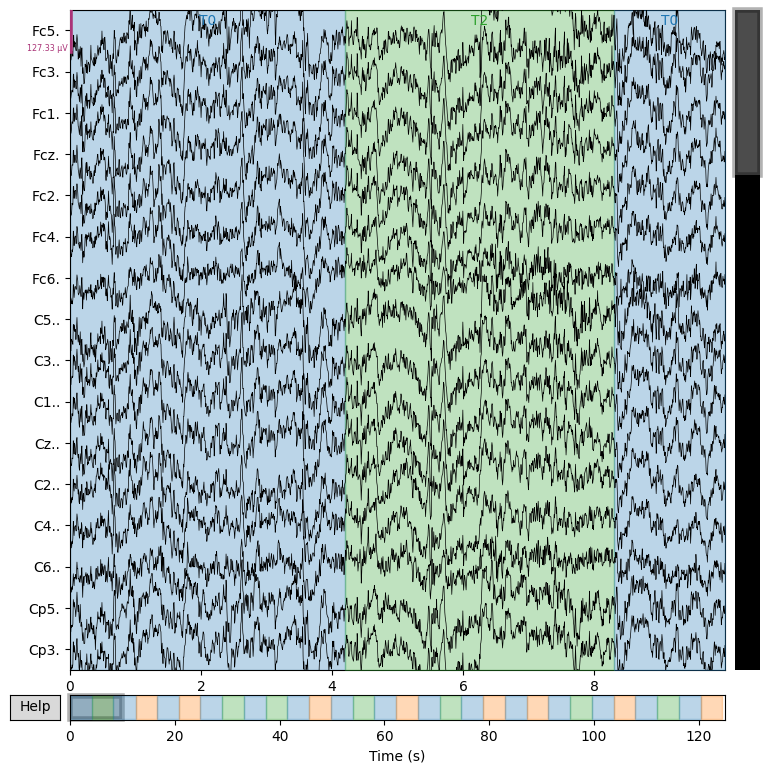

In [ ]:
raw_list[0].plot(
    duration=10,
    n_channels=16,
    scalings="auto"
)

plt.show()

In [ ]:
filtered_list = []

for raw_data in raw_list:

    raw_filtered = raw_data.copy()

    raw_filtered.filter(
        l_freq=1,
        h_freq=40,
        verbose=False
    )

    filtered_list.append(raw_filtered)

print("Band-pass filtering completed!")
print("Frequency range: 1–40 Hz")

Band-pass filtering completed!
Frequency range: 1–40 Hz


For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


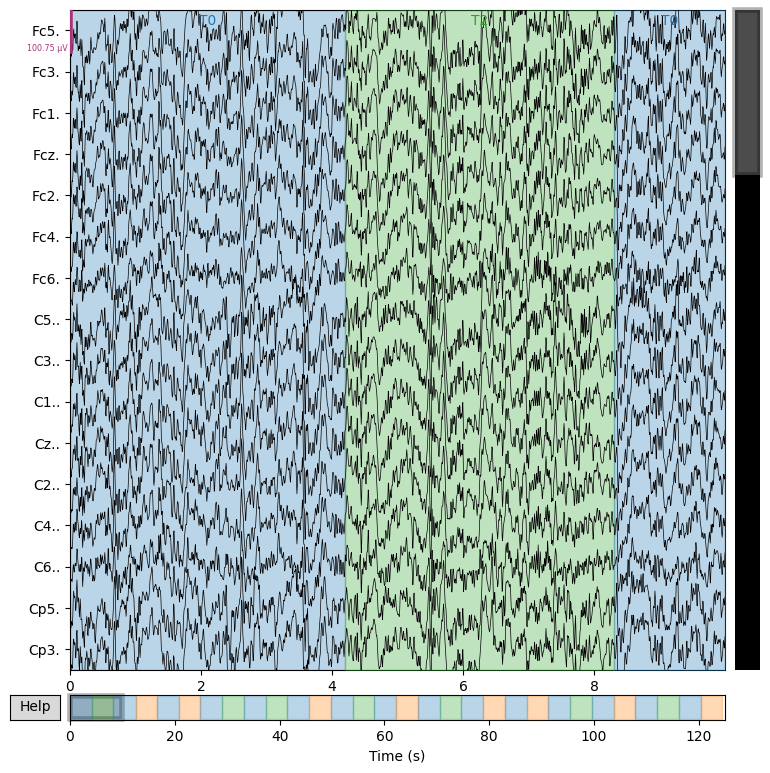

In [ ]:
filtered_list[0].plot(
    duration=10,
    n_channels=16,
    scalings="auto"
)

plt.show()

In [ ]:
epochs_list = []

for i, raw_data in enumerate(filtered_list):

    print("\n" + "=" * 50)

    print("Processing:",
          os.path.basename(files[i]))

    # Convert annotations into events
    events, event_dict = mne.events_from_annotations(
        raw_data,
        verbose=False
    )

    print("Available events:")
    print(event_dict)

    # Select only T1 and T2
    selected_events = {
        key: value
        for key, value in event_dict.items()
        if key in ["T1", "T2"]
    }

    print("\nSelected events:")
    print(selected_events)

    # Check whether T1/T2 exist
    if not selected_events:

        print("No T1/T2 events found. Skipping recording.")
        continue

    # Create 4-second epochs
    epochs = mne.Epochs(
        raw_data,
        events,
        event_id=selected_events,
        tmin=0,
        tmax=4,
        baseline=None,
        preload=True,
        reject=None,
        reject_by_annotation=False,
        verbose=False
    )

    print("Number of epochs:", len(epochs))

    if len(epochs) > 0:
        epochs_list.append(epochs)

print("\nValid epoch groups:", len(epochs_list))


Processing: S001R04.edf
Available events:
{'T0': 1, 'T1': 2, 'T2': 3}

Selected events:
{'T1': 2, 'T2': 3}
Number of epochs: 15

Processing: S001R08.edf
Available events:
{'T0': 1, 'T1': 2, 'T2': 3}

Selected events:
{'T1': 2, 'T2': 3}
Number of epochs: 15

Processing: S001R12.edf
Available events:
{'T0': 1, 'T1': 2, 'T2': 3}

Selected events:
{'T1': 2, 'T2': 3}
Number of epochs: 15

Valid epoch groups: 3


In [ ]:
all_epochs = mne.concatenate_epochs(
    epochs_list,
    on_mismatch="warn"
)

print(all_epochs)

print("\nNumber of epochs:",
      len(all_epochs))

print("Number of channels:",
      len(all_epochs.ch_names))

print("Sampling frequency:",
      all_epochs.info["sfreq"],
      "Hz")

Not setting metadata
45 matching events found
No baseline correction applied
<EpochsArray | 45 events (all good), 0 – 4 s (baseline off), ~14.1 MiB, data loaded,
 'T1': 23
 'T2': 22>

Number of epochs: 45
Number of channels: 64
Sampling frequency: 160.0 Hz


/tmp/ipykernel_2332/418889146.py:1: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  all_epochs = mne.concatenate_epochs(


In [ ]:
data = all_epochs.get_data()

print("EEG data shape:")
print(data.shape)

print("\nMeaning:")

print("Number of epochs  :", data.shape[0])
print("Number of channels:", data.shape[1])
print("Number of samples :", data.shape[2])

EEG data shape:
(45, 64, 641)

Meaning:
Number of epochs  : 45
Number of channels: 64
Number of samples : 641


In [ ]:
print("Event ID:")
print(all_epochs.event_id)

print("\nEvent codes:")
print(all_epochs.events[:, 2])

Event ID:
{'T1': 2, 'T2': 3}

Event codes:
[3 2 2 3 3 2 3 2 3 2 2 3 2 3 2 2 3 2 3 2 3 2 3 3 2 2 3 3 2 2 3 2 3 2 2 3 3
 2 2 3 3 2 3 2 3]


In [ ]:
event_id = all_epochs.event_id

code_to_label = {
    value: key
    for key, value in event_id.items()
}

labels = np.array([
    code_to_label[event_code]
    for event_code in all_epochs.events[:, 2]
])

print("Labels:")
print(labels)

Labels:
['T2' 'T1' 'T1' 'T2' 'T2' 'T1' 'T2' 'T1' 'T2' 'T1' 'T1' 'T2' 'T1' 'T2'
 'T1' 'T1' 'T2' 'T1' 'T2' 'T1' 'T2' 'T1' 'T2' 'T2' 'T1' 'T1' 'T2' 'T2'
 'T1' 'T1' 'T2' 'T1' 'T2' 'T1' 'T1' 'T2' 'T2' 'T1' 'T1' 'T2' 'T2' 'T1'
 'T2' 'T1' 'T2']


In [ ]:
unique_labels, counts = np.unique(
    labels,
    return_counts=True
)

print("Class distribution:")

for label, count in zip(unique_labels, counts):

    print(label, ":", count)

Class distribution:
T1 : 23
T2 : 22


In [ ]:
n_epochs, n_channels, n_samples = data.shape

data_normalized = np.zeros_like(data)

for epoch in range(n_epochs):

    for channel in range(n_channels):

        scaler = StandardScaler()

        data_normalized[
            epoch,
            channel,
            :
        ] = scaler.fit_transform(
            data[
                epoch,
                channel,
                :
            ].reshape(-1, 1)
        ).flatten()

print("Normalization completed!")

print("\nNormalized data shape:")
print(data_normalized.shape)

Normalization completed!

Normalized data shape:
(45, 64, 641)


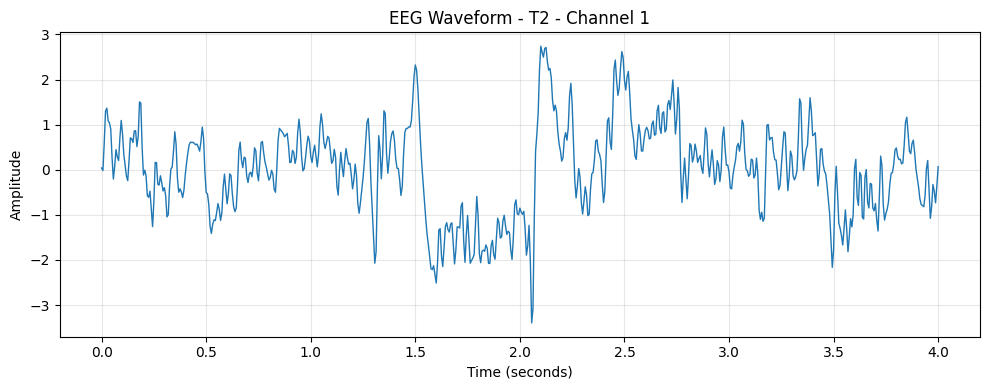

In [ ]:
epoch_number = 0
channel_number = 0

signal = data_normalized[
    epoch_number,
    channel_number,
    :
]

fs = all_epochs.info["sfreq"]

# Create time axis
time = np.arange(len(signal)) / fs

plt.figure(figsize=(10, 4))

plt.plot(
    time,
    signal,
    linewidth=1
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.title(
    f"EEG Waveform - "
    f"{labels[epoch_number]} - "
    f"Channel {channel_number + 1}"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
output_folder = "EEG_images"

# Remove old folder if you want a completely fresh dataset
import shutil

if os.path.exists(output_folder):
    shutil.rmtree(output_folder)

# Create new folders
os.makedirs(
    os.path.join(output_folder, "T1"),
    exist_ok=True
)

os.makedirs(
    os.path.join(output_folder, "T2"),
    exist_ok=True
)

print("Fresh image folders created!")

print("\nFolder structure:")

print("EEG_images/")
print("├── T1/")
print("└── T2/")

Fresh image folders created!

Folder structure:
EEG_images/
├── T1/
└── T2/


In [ ]:
print("Starting EEG waveform image generation...")

for epoch_number in range(n_epochs):

    # Select Channel 1
    signal = data_normalized[
        epoch_number,
        0,
        :
    ]

    # Get T1 or T2 label
    label = labels[epoch_number]

    # Create time axis
    time = np.arange(len(signal)) / fs

    # Create figure
    plt.figure(figsize=(5, 4))

    # Plot EEG waveform
    plt.plot(
        time,
        signal,
        linewidth=1
    )

    # Remove axes
    plt.axis("off")

    # Remove extra space
    plt.tight_layout(pad=0)

    # Output filename
    filename = os.path.join(
        output_folder,
        label,
        f"epoch_{epoch_number:04d}.png"
    )

    # Save image
    plt.savefig(
        filename,
        dpi=150,
        bbox_inches="tight",
        pad_inches=0
    )

    plt.close()

print("\nEEG WAVEFORM IMAGE GENERATION COMPLETED!")

print("Total images generated:",
      n_epochs)

Starting EEG waveform image generation...

EEG WAVEFORM IMAGE GENERATION COMPLETED!
Total images generated: 45


In [ ]:
t1_folder = os.path.join(
    output_folder,
    "T1"
)

t2_folder = os.path.join(
    output_folder,
    "T2"
)

t1_images = [
    f
    for f in os.listdir(t1_folder)
    if f.endswith(".png")
]

t2_images = [
    f
    for f in os.listdir(t2_folder)
    if f.endswith(".png")
]

print("T1 images:", len(t1_images))

print("T2 images:", len(t2_images))

print(
    "Total images:",
    len(t1_images) + len(t2_images)
)

T1 images: 23
T2 images: 22
Total images: 45


Displaying T1 image:
EEG_images/T1/epoch_0001.png


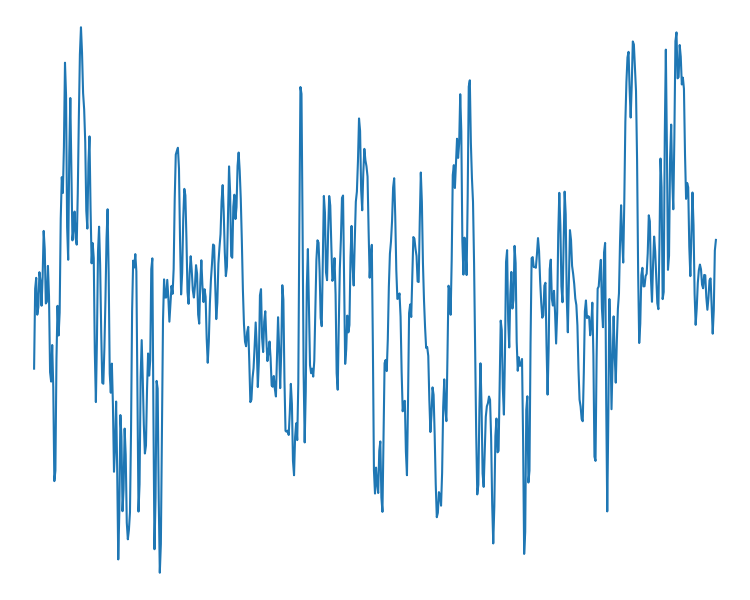

In [ ]:
from IPython.display import Image, display

t1_files = sorted(
    os.listdir(t1_folder)
)

if len(t1_files) > 0:

    image_path = os.path.join(
        t1_folder,
        t1_files[0]
    )

    print("Displaying T1 image:")
    print(image_path)

    display(
        Image(
            filename=image_path
        )
    )

else:

    print("No T1 images found!")

Displaying T2 image:
EEG_images/T2/epoch_0000.png


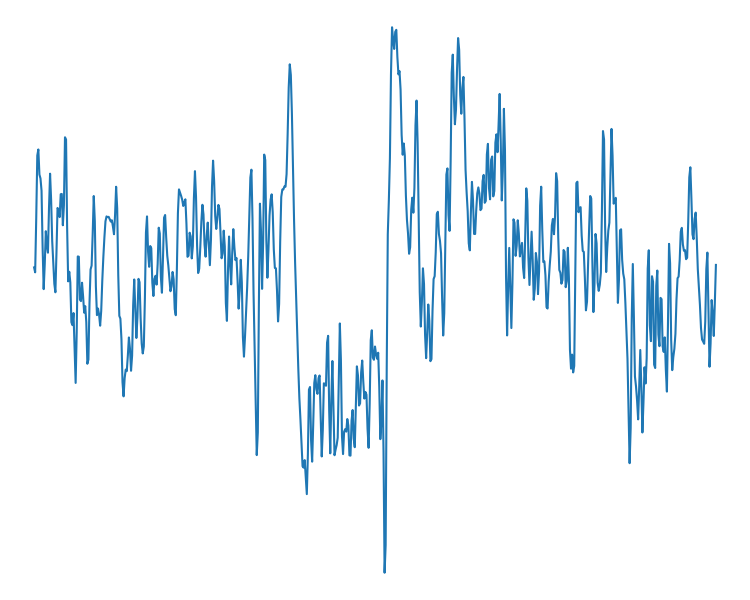

In [ ]:
t2_files = sorted(
    os.listdir(t2_folder)
)

if len(t2_files) > 0:

    image_path = os.path.join(
        t2_folder,
        t2_files[0]
    )

    print("Displaying T2 image:")
    print(image_path)

    display(
        Image(
            filename=image_path
        )
    )

else:

    print("No T2 images found!")

In [ ]:
from IPython.display import display, Image

print("=" * 50)
print("T1 EEG WAVEFORM EXAMPLES")
print("=" * 50)

for filename in t1_files[:5]:

    path = os.path.join(
        t1_folder,
        filename
    )

    print(filename)

    display(
        Image(filename=path)
    )


print("\n" + "=" * 50)
print("T2 EEG WAVEFORM EXAMPLES")
print("=" * 50)

for filename in t2_files[:5]:

    path = os.path.join(
        t2_folder,
        filename
    )

    print(filename)

    display(
        Image(filename=path)
    )

In [ ]:
print("=" * 60)
print("EEG WAVEFORM IMAGE DATASET SUMMARY")
print("=" * 60)

print("\nEEG INFORMATION")

print("Total epochs      :", n_epochs)

print("EEG channels      :", n_channels)

print("Samples per epoch :", n_samples)

print("Sampling rate     :", fs, "Hz")

print("\nCLASS INFORMATION")

print("T1 images         :", len(t1_images))

print("T2 images         :", len(t2_images))

print("Total images      :",
      len(t1_images) + len(t2_images))

print("\nIMAGE DIRECTORY")

print(os.path.abspath(output_folder))

print("\nPROCESSING PIPELINE")

print("Raw EEG")
print("   ↓")
print("1–40 Hz Band-pass Filter")
print("   ↓")
print("T1/T2 Event Extraction")
print("   ↓")
print("4-second Epoching")
print("   ↓")
print("Channel-wise Normalization")
print("   ↓")
print("Raw EEG Waveform")
print("   ↓")
print("PNG Image")
print("   ↓")
print("T1 / T2 Dataset")

print("\n" + "=" * 60)
print("NO SPECTROGRAM USED")
print("=" * 60)

EEG WAVEFORM IMAGE DATASET SUMMARY

EEG INFORMATION
Total epochs      : 45
EEG channels      : 64
Samples per epoch : 641
Sampling rate     : 160.0 Hz

CLASS INFORMATION
T1 images         : 23
T2 images         : 22
Total images      : 45

IMAGE DIRECTORY
/content/EEG_images

PROCESSING PIPELINE
Raw EEG
   ↓
1–40 Hz Band-pass Filter
   ↓
T1/T2 Event Extraction
   ↓
4-second Epoching
   ↓
Channel-wise Normalization
   ↓
Raw EEG Waveform
   ↓
PNG Image
   ↓
T1 / T2 Dataset

NO SPECTROGRAM USED
